In [2]:
#Winning in First Three Strokes?
import pandas as pd
ttdynamics = pd.read_csv('table_tennis_data.csv')
ttdynamics['Winning in First Three Strokes'].value_counts(normalize=True)
# 1 = Yes
# 0 = No

Winning in First Three Strokes
1    0.593333
0    0.406667
Name: proportion, dtype: float64

In [3]:
#Average rally duration(Since this is not in the dataset, I will calculate it by assuming that shortrally are around 2.3 strokes and longrally are around 5.3 strokes)
# short rally = 2.3 because it is unlikely that a rally will end in either serve or serve recieve
# long rally = 5.3 because it is 4 strokes and above but it is unlikely to go beyond 6 strokes
avg = (0.593333 * 2.3) + (0.486667 * 5.3)
print(avg)

3.944001


In [4]:
#Topspin or Backspin?
ttdynamics['Topspin/Backspin Indicator'].value_counts(normalize=True)
# 1 = Topspin
# 0 = Backspin

Topspin/Backspin Indicator
1    0.657333
0    0.342667
Name: proportion, dtype: float64

In [5]:
#Forehand or Backhand?
ttdynamics['Forehand/Backhand Indicator'].value_counts(normalize=True)
# 1 = Forehand
# 0 = Backhand

Forehand/Backhand Indicator
1    0.657333
0    0.342667
Name: proportion, dtype: float64

In [6]:
#Average X Y Position
positionX = ttdynamics['X'].mean()
positionY = ttdynamics['Y'].mean()
print(f"Average Position - X: {positionX}, Y: {positionY}")

Average Position - X: 109.534, Y: 60.56466666666667


In [7]:
#Player Win Rates(out of the total matches)(of the second dataset)
monthtt = pd.read_csv('Setka.csv')
monthtt['p1won'] = monthtt['Sets_P1'] == 3
monthtt['p2won'] = monthtt['Sets_P2'] == 3
dicwon = {}
diclost = {}
for i in range(len(monthtt)):
    if monthtt['p1won'].iloc[i] == True:
        if monthtt['Player1'].iloc[i] not in dicwon:
            dicwon[monthtt['Player1'].iloc[i]] = 1
        else:
            dicwon[monthtt['Player1'].iloc[i]] += 1
        if monthtt['Player2'].iloc[i] not in diclost:
            diclost[monthtt['Player2'].iloc[i]] = 1
        else:
            diclost[monthtt['Player2'].iloc[i]] += 1
    else:
        if monthtt['Player1'].iloc[i] not in diclost:
            diclost[monthtt['Player1'].iloc[i]] = 1
        else:
            diclost[monthtt['Player1'].iloc[i]] += 1
        if monthtt['Player2'].iloc[i] not in dicwon:
            dicwon[monthtt['Player2'].iloc[i]] = 1
        else:
            dicwon[monthtt['Player2'].iloc[i]] += 1
winrate = {}
for player in dicwon:
    if player not in diclost:
        diclost[player] = 0
    elif player not in dicwon:
        dicwon[player] = 0
    wrate = dicwon[player] / (diclost[player] + dicwon[player])
    winrate[player] = wrate
print(winrate)

{'Marchuk M.': 0.40625, 'Sachuk S.': 0.6571428571428571, 'Samofal Y.': 0.65625, 'Kyilo V.': 0.4520547945205479, 'Polysynskyi M.': 0.41333333333333333, 'Diachenko M.': 0.4810126582278481, 'Balakiriev M.': 0.5, 'Hryshchenko O.': 0.5443037974683544, 'Sokolov S.': 0.6714285714285714, 'Bambutsa R.': 0.4528301886792453, 'Baday M.': 0.7428571428571429, 'Lutskyi V.': 0.4, 'Hordiichuk O.': 0.45, 'Zaitsev O.': 0.4666666666666667, 'Vons V.': 0.72, 'Nikolenko S.': 0.42857142857142855, 'Fedoryshyn I.': 0.6231884057971014, 'Stukalov V.': 0.5882352941176471, 'Mishchenko V.': 0.4897959183673469, 'Fylypiv R.': 0.6, 'Semipeadnii V.': 0.2903225806451613, 'Rak S.': 0.6344086021505376, 'Ponomarenko O.': 0.5428571428571428, 'Kolbasenko O.': 0.5714285714285714, 'Mul S.': 0.8888888888888888, 'Marko J.': 0.5, 'Cherevko R.': 0.3076923076923077, 'Kunchurov D.': 0.47619047619047616, 'Sklyarenko A.': 0.52, 'Brozek M.': 0.5909090909090909, 'Dubrovin V.': 0.6829268292682927, 'Mikus D.': 0.6428571428571429, 'Slozka M

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv('Setka.csv')

df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.date

player_stats = []

all_players = set(df['Player1'].unique()) | set(df['Player2'].unique())

for player in all_players:
    player1_matches = df[df['Player1'] == player].copy()
    player2_matches = df[df['Player2'] == player].copy()

    player1_matches['won'] = player1_matches['HomeWinner'] == 1

    player2_matches['won'] = player2_matches['HomeWinner'] == 0

    player_matches = pd.concat([
        player1_matches[['Date', 'Day', 'won']],
        player2_matches[['Date', 'Day', 'won']]
    ])

    total_matches = len(player_matches)
    total_wins = player_matches['won'].sum()
    overall_winrate = (total_wins / total_matches * 100) if total_matches > 0 else 0

    if total_matches < 10:
        continue

    # Calculate average days between matches (FIXED LOGIC)
    # Sort all matches by date
    player_matches_sorted = player_matches.sort_values('Date').reset_index(drop=True)
    
    if len(player_matches_sorted) > 1:
        day_differences = []
        for i in range(1, len(player_matches_sorted)):
            prev_day = player_matches_sorted.loc[i-1, 'Day']
            curr_day = player_matches_sorted.loc[i, 'Day']
            diff = (pd.to_datetime(curr_day) - pd.to_datetime(prev_day)).days
            day_differences.append(diff)
        avg_days_between_matches = np.mean(day_differences)
    else:
        avg_days_between_matches = 0

    daily_stats = player_matches.groupby('Day').agg({
        'won': ['sum', 'count']
    })
    daily_stats.columns = ['wins', 'matches']
    daily_stats['winrate'] = (daily_stats['wins'] / daily_stats['matches'] * 100)
    
    if len(daily_stats) > 0:
        highest_daily_winrate = daily_stats['winrate'].max()
        lowest_daily_winrate = daily_stats['winrate'].min()
        winrate_difference = highest_daily_winrate - lowest_daily_winrate
    else:
        highest_daily_winrate = 0
        lowest_daily_winrate = 0
        winrate_difference = 0

    player_stats.append({
        'Player Name': player,
        'Total Matches': total_matches,
        'Overall Win Rate (%)': round(overall_winrate, 2),
        'Highest Daily Win Rate (%)': round(highest_daily_winrate, 2),
        'Lowest Daily Win Rate (%)': round(lowest_daily_winrate, 2),
        'Win Rate Difference (%)': round(winrate_difference, 2),
        'Avg Days Between Matches': round(avg_days_between_matches, 2)
    })

result_df = pd.DataFrame(player_stats)

result_df = result_df.sort_values('Overall Win Rate (%)', ascending=False).reset_index(drop=True)

# Set pandas display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(result_df)

# A dataset that shows each player's total matches, overall win rate, highest and lowest daily win rates, and the difference between highest and lowest daily win rates,
# win rate = win/total matches played on that day * 100
# highest daily win rate = highest win rate achieved by the player on any single day
# lowest daily win rate = lowest win rate achieved by the player on any single day
# Avg Days Between Matches = average number of days between EACH INDIVIDUAL match (not just between unique days)
# Example: 5 matches on Day 1, 5 matches on Day 11 = (0+0+0+0+10+0+0+0+0)/9 = 1.11 days average
# Note that only players with at least 10 matches are included in the dataset. So that the data is more reliable.

        Player Name  Total Matches  Overall Win Rate (%)  \
0         Kostyv M.             10                100.00   
1         Bouska M.             11                100.00   
2    Sokolovskyi S.             20                 95.00   
3          Bulat P.             14                 92.86   
4          Bosak D.             10                 90.00   
..              ...            ...                   ...   
447      Priadko Y.             10                 10.00   
448   Kononikhin V.             11                  9.09   
449      Mykytuk D.             14                  7.14   
450         Reva V.             20                  5.00   
451      Yamchuk V.             18                  0.00   

     Highest Daily Win Rate (%)  Lowest Daily Win Rate (%)  \
0                         100.0                      100.0   
1                         100.0                      100.0   
2                         100.0                       80.0   
3                         100.0


=== Win Rate Statistics ===
Mean Win Rate: 49.75%
Median Win Rate: 50.00%
Std Deviation: 14.78%
Min Win Rate: 0.00%
Max Win Rate: 100.00%


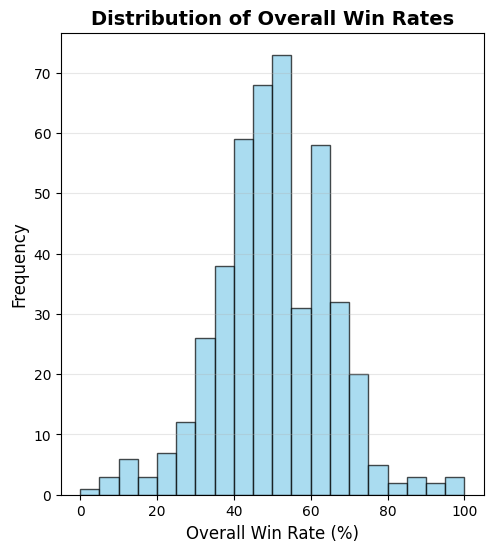

In [9]:
fig1 = plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(result_df['Overall Win Rate (%)'], bins=20, edgecolor='black', color='skyblue', alpha=0.7)
plt.xlabel('Overall Win Rate (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Overall Win Rates', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

print("\n=== Win Rate Statistics ===")
print(f"Mean Win Rate: {result_df['Overall Win Rate (%)'].mean():.2f}%")
print(f"Median Win Rate: {result_df['Overall Win Rate (%)'].median():.2f}%")
print(f"Std Deviation: {result_df['Overall Win Rate (%)'].std():.2f}%")
print(f"Min Win Rate: {result_df['Overall Win Rate (%)'].min():.2f}%")
print(f"Max Win Rate: {result_df['Overall Win Rate (%)'].max():.2f}%")

#Most players in the club have a win rate between 34.97% and 64.53% which indicates that most players' skill levels are in the middle range. Most players are neither beginners nor advanced players.

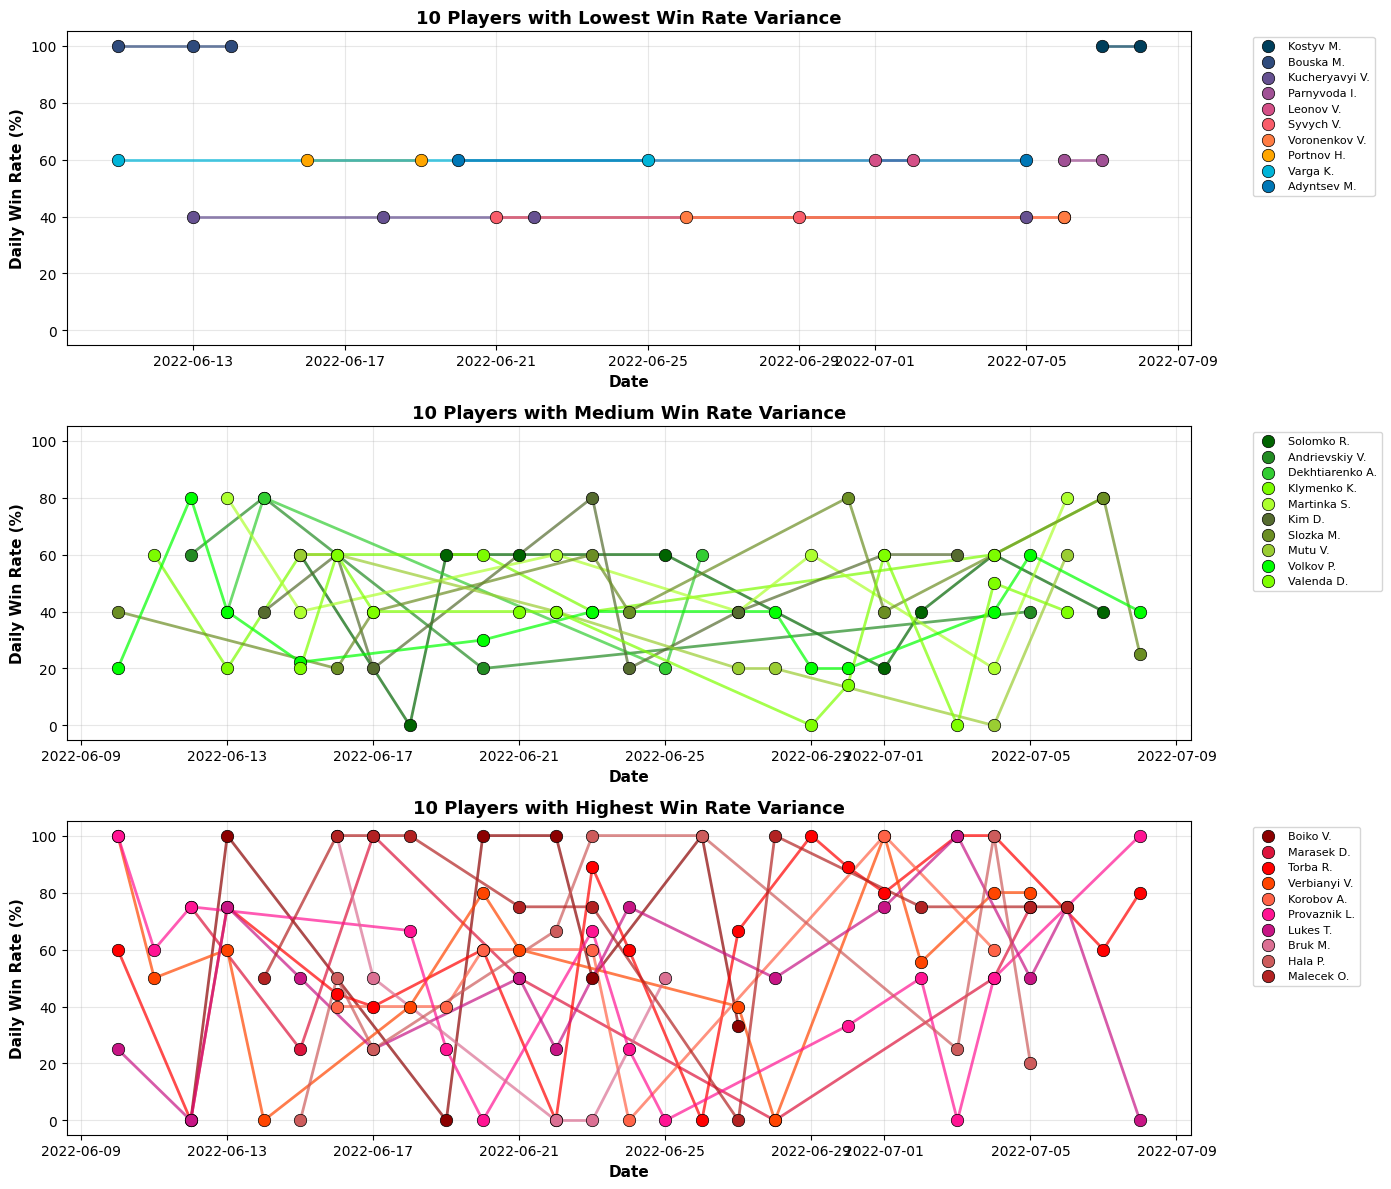

In [10]:
player_daily_data = {}

for player in result_df['Player Name']:
    player1_matches = df[df['Player1'] == player].copy()
    player2_matches = df[df['Player2'] == player].copy()
    
    player1_matches['won'] = player1_matches['HomeWinner'] == 1
    player2_matches['won'] = player2_matches['HomeWinner'] == 0
    
    player_matches = pd.concat([
        player1_matches[['Date', 'Day', 'won']],
        player2_matches[['Date', 'Day', 'won']]
    ])
    
    daily_stats = player_matches.groupby('Day').agg({
        'won': ['sum', 'count']
    })
    daily_stats.columns = ['wins', 'matches']
    daily_stats['winrate'] = (daily_stats['wins'] / daily_stats['matches'] * 100)
    daily_stats = daily_stats.reset_index()
    
    player_daily_data[player] = daily_stats

result_df_sorted = result_df.sort_values('Win Rate Difference (%)')

n_players = len(result_df_sorted)
if n_players >= 30:
    low_variance_players = result_df_sorted.head(10)['Player Name'].tolist()
    medium_variance_players = result_df_sorted.iloc[n_players//2 - 5:n_players//2 + 5]['Player Name'].tolist()
    high_variance_players = result_df_sorted.tail(10)['Player Name'].tolist()
else:
    n_per_group = n_players // 3
    low_variance_players = result_df_sorted.head(n_per_group)['Player Name'].tolist()
    medium_variance_players = result_df_sorted.iloc[n_per_group:2*n_per_group]['Player Name'].tolist()
    high_variance_players = result_df_sorted.tail(n_per_group)['Player Name'].tolist()

fig2, axes = plt.subplots(3, 1, figsize=(14, 12))

def plot_variance_group(ax, players, title, colors):
    for idx, player in enumerate(players):
        if player in player_daily_data:
            data = player_daily_data[player].sort_values('Day')
            color = colors[idx]
            
            ax.plot(data['Day'], data['winrate'], 
                   color=color, alpha=0.7, linewidth=2, linestyle='-')
            
            ax.scatter(data['Day'], data['winrate'], 
                      label=player, s=80, color=color, 
                      edgecolors='black', linewidth=0.5, zorder=5)
    
    ax.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax.set_ylabel('Daily Win Rate (%)', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 105)

colors_low = ['#003f5c', '#2f4b7c', '#665191', '#a05195', '#d45087', 
              '#f95d6a', '#ff7c43', '#ffa600', '#00b4d8', '#0077b6']
colors_med = ['#006400', '#228b22', '#32cd32', '#7cfc00', '#adff2f',
              '#556b2f', '#6b8e23', '#9acd32', '#00ff00', '#7fff00']
colors_high = ['#8b0000', '#dc143c', '#ff0000', '#ff4500', '#ff6347',
               '#ff1493', '#c71585', '#db7093', '#cd5c5c', '#b22222']

plot_variance_group(axes[0], low_variance_players, 
                   '10 Players with Lowest Win Rate Variance', colors_low)
plot_variance_group(axes[1], medium_variance_players, 
                   '10 Players with Medium Win Rate Variance', colors_med)
plot_variance_group(axes[2], high_variance_players, 
                   '10 Players with Highest Win Rate Variance', colors_high)

plt.tight_layout()
plt.show()

# The win rate variances is calculated by finding the difference between the highest and lowest daily win rates for each player. These graphs show the daily win rates of players with low, medium, and high variances respectively.

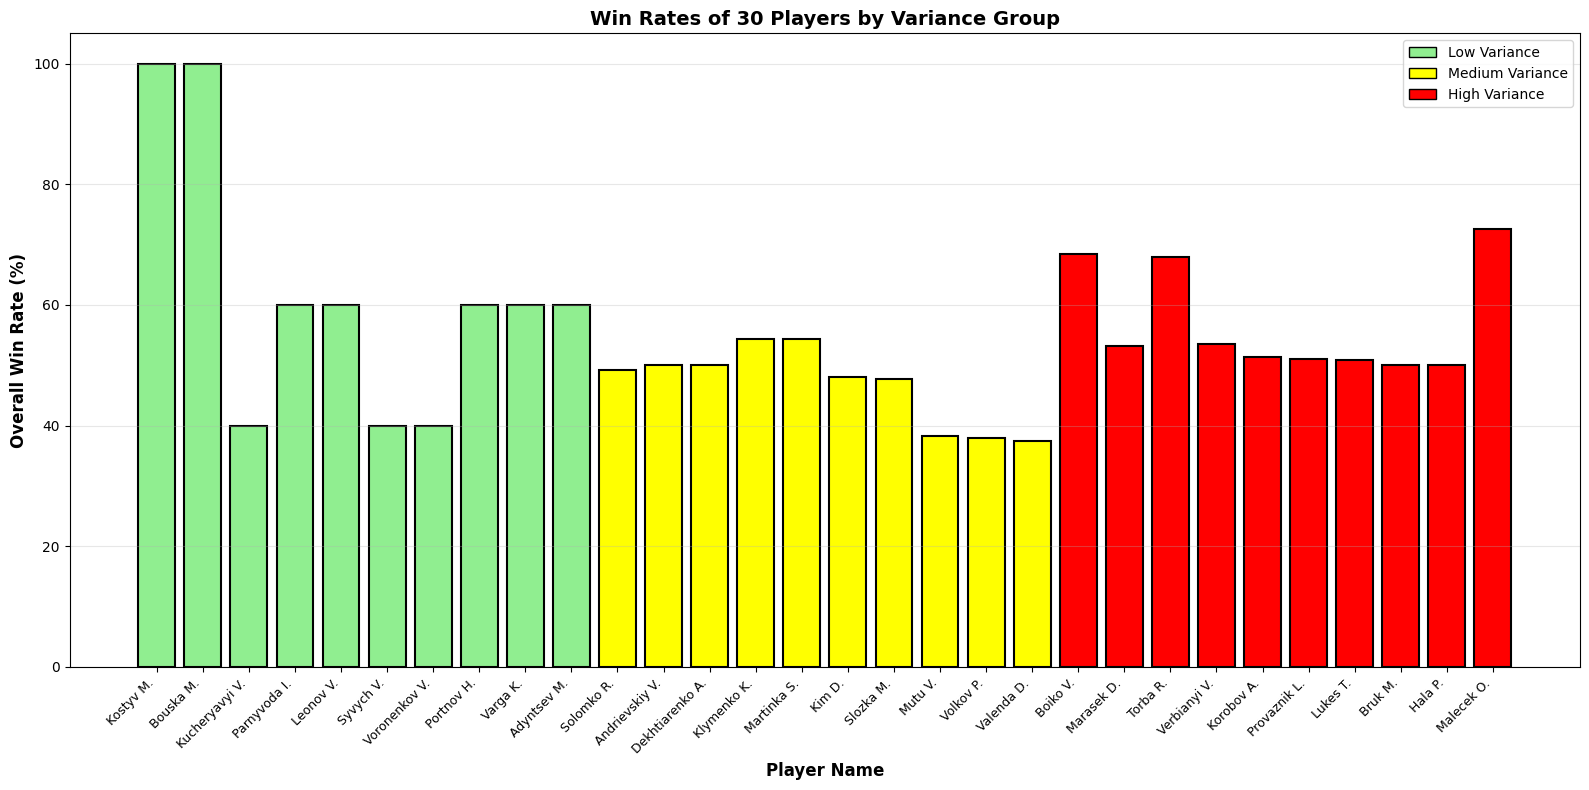

In [11]:
fig3, ax = plt.subplots(figsize=(16, 8))

selected_players_data = []

for player in low_variance_players:
    winrate = result_df[result_df['Player Name'] == player]['Overall Win Rate (%)'].values[0]
    selected_players_data.append({'Player': player, 'Win Rate': winrate, 'Group': 'Low Variance'})

for player in medium_variance_players:
    winrate = result_df[result_df['Player Name'] == player]['Overall Win Rate (%)'].values[0]
    selected_players_data.append({'Player': player, 'Win Rate': winrate, 'Group': 'Medium Variance'})

for player in high_variance_players:
    winrate = result_df[result_df['Player Name'] == player]['Overall Win Rate (%)'].values[0]
    selected_players_data.append({'Player': player, 'Win Rate': winrate, 'Group': 'High Variance'})

histogram_df = pd.DataFrame(selected_players_data)

color_map = {'Low Variance': 'lightgreen', 'Medium Variance': 'yellow', 'High Variance': 'red'}
colors = [color_map[group] for group in histogram_df['Group']]

bars = ax.bar(range(len(histogram_df)), histogram_df['Win Rate'], color=colors, edgecolor='black', linewidth=1.5)

ax.set_xticks(range(len(histogram_df)))
ax.set_xticklabels(histogram_df['Player'], rotation=45, ha='right', fontsize=9)

ax.set_xlabel('Player Name', fontsize=12, fontweight='bold')
ax.set_ylabel('Overall Win Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Win Rates of 30 Players by Variance Group', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

legend_elements = [
    Patch(facecolor='lightgreen', edgecolor='black', label='Low Variance'),
    Patch(facecolor='yellow', edgecolor='black', label='Medium Variance'),
    Patch(facecolor='red', edgecolor='black', label='High Variance')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# This histogram shows the overall win rates of 30 selected players categorized by their win rate variance groups: low, medium, and high. Each group is represented by a different color for easy identification.
# Based on this histogram, the win rate variances of each player doesn't have any correlation with their overall win rates.

In [12]:
# Create three separate tables based on variance groups

# High Variance Table (Top 10 highest variance)
high_variance_df = result_df[result_df['Player Name'].isin(high_variance_players)].copy()
high_variance_df = high_variance_df.sort_values('Win Rate Difference (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("HIGH VARIANCE PLAYERS (Top 10 Highest Win Rate Variance)")
print("="*100)
print(high_variance_df)
print("-"*100)
print(f"MEAN VALUES:")
print(f"Total Matches: {high_variance_df['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {high_variance_df['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {high_variance_df['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {high_variance_df['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {high_variance_df['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {high_variance_df['Avg Days Between Matches'].mean():.2f}")

# Medium Variance Table (Middle 10 players)
medium_variance_df = result_df[result_df['Player Name'].isin(medium_variance_players)].copy()
medium_variance_df = medium_variance_df.sort_values('Win Rate Difference (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("MEDIUM VARIANCE PLAYERS (Middle 10 Players)")
print("="*100)
print(medium_variance_df)
print("-"*100)
print(f"MEAN VALUES:")
print(f"Total Matches: {medium_variance_df['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {medium_variance_df['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {medium_variance_df['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {medium_variance_df['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {medium_variance_df['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {medium_variance_df['Avg Days Between Matches'].mean():.2f}")

# Low Variance Table (Bottom 10 lowest variance)
low_variance_df = result_df[result_df['Player Name'].isin(low_variance_players)].copy()
low_variance_df = low_variance_df.sort_values('Win Rate Difference (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print("LOW VARIANCE PLAYERS (Bottom 10 Lowest Win Rate Variance)")
print("="*100)
print(low_variance_df)
print("-"*100)
print(f"MEAN VALUES:")
print(f"Total Matches: {low_variance_df['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {low_variance_df['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {low_variance_df['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {low_variance_df['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {low_variance_df['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {low_variance_df['Avg Days Between Matches'].mean():.2f}")


HIGH VARIANCE PLAYERS (Top 10 Highest Win Rate Variance)
    Player Name  Total Matches  Overall Win Rate (%)  \
0    Malecek O.             40                 72.50   
1      Boiko V.             19                 68.42   
2      Torba R.             78                 67.95   
3  Verbianyi V.             58                 53.45   
4    Marasek D.             32                 53.12   
5    Korobov A.             35                 51.43   
6  Provaznik L.             47                 51.06   
7      Lukes T.             53                 50.94   
8       Bruk M.             16                 50.00   
9       Hala P.             28                 50.00   

   Highest Daily Win Rate (%)  Lowest Daily Win Rate (%)  \
0                       100.0                        0.0   
1                       100.0                        0.0   
2                       100.0                        0.0   
3                       100.0                        0.0   
4                       1

In [13]:
# Create tables with 50 players each based on variance groups

result_df_sorted_50 = result_df.sort_values('Win Rate Difference (%)')

n_players_50 = len(result_df_sorted_50)
if n_players_50 >= 150:
    low_variance_players_50 = result_df_sorted_50.head(50)['Player Name'].tolist()
    medium_variance_players_50 = result_df_sorted_50.iloc[n_players_50//2 - 25:n_players_50//2 + 25]['Player Name'].tolist()
    high_variance_players_50 = result_df_sorted_50.tail(50)['Player Name'].tolist()
else:
    n_per_group_50 = min(50, n_players_50 // 3)
    low_variance_players_50 = result_df_sorted_50.head(n_per_group_50)['Player Name'].tolist()
    medium_variance_players_50 = result_df_sorted_50.iloc[n_per_group_50:2*n_per_group_50]['Player Name'].tolist()
    high_variance_players_50 = result_df_sorted_50.tail(n_per_group_50)['Player Name'].tolist()

# High Variance Table (Top 50 highest variance)
high_variance_df_50 = result_df[result_df['Player Name'].isin(high_variance_players_50)].copy()

print("\n" + "="*100)
print("HIGH VARIANCE PLAYERS (Top 50 Highest Win Rate Variance) - MEAN VALUES")
print("="*100)
print(f"Number of Players: {len(high_variance_df_50)}")
print(f"Total Matches: {high_variance_df_50['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {high_variance_df_50['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {high_variance_df_50['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {high_variance_df_50['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {high_variance_df_50['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {high_variance_df_50['Avg Days Between Matches'].mean():.2f}")

# Medium Variance Table (Middle 50 players)
medium_variance_df_50 = result_df[result_df['Player Name'].isin(medium_variance_players_50)].copy()

print("\n" + "="*100)
print("MEDIUM VARIANCE PLAYERS (Middle 50 Players) - MEAN VALUES")
print("="*100)
print(f"Number of Players: {len(medium_variance_df_50)}")
print(f"Total Matches: {medium_variance_df_50['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {medium_variance_df_50['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {medium_variance_df_50['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {medium_variance_df_50['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {medium_variance_df_50['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {medium_variance_df_50['Avg Days Between Matches'].mean():.2f}")

# Low Variance Table (Bottom 50 lowest variance)
low_variance_df_50 = result_df[result_df['Player Name'].isin(low_variance_players_50)].copy()

print("\n" + "="*100)
print("LOW VARIANCE PLAYERS (Bottom 50 Lowest Win Rate Variance) - MEAN VALUES")
print("="*100)
print(f"Number of Players: {len(low_variance_df_50)}")
print(f"Total Matches: {low_variance_df_50['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {low_variance_df_50['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {low_variance_df_50['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {low_variance_df_50['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {low_variance_df_50['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {low_variance_df_50['Avg Days Between Matches'].mean():.2f}")


HIGH VARIANCE PLAYERS (Top 50 Highest Win Rate Variance) - MEAN VALUES
Number of Players: 50
Total Matches: 43.66
Overall Win Rate (%): 51.44
Highest Daily Win Rate (%): 100.00
Lowest Daily Win Rate (%): 0.00
Win Rate Difference (%): 100.00
Avg Days Between Matches: 0.64

MEDIUM VARIANCE PLAYERS (Middle 50 Players) - MEAN VALUES
Number of Players: 50
Total Matches: 32.30
Overall Win Rate (%): 46.84
Highest Daily Win Rate (%): 74.40
Lowest Daily Win Rate (%): 14.40
Win Rate Difference (%): 60.00
Avg Days Between Matches: 0.71

LOW VARIANCE PLAYERS (Bottom 50 Lowest Win Rate Variance) - MEAN VALUES
Number of Players: 50
Total Matches: 15.80
Overall Win Rate (%): 50.44
Highest Daily Win Rate (%): 57.30
Lowest Daily Win Rate (%): 43.80
Win Rate Difference (%): 13.50
Avg Days Between Matches: 0.89


In [14]:
# Find information about Adyntsev M.
player_name = "Pavliuk V."

# Get all matches for this player
player1_matches = df[df['Player1'] == player_name].copy()
player2_matches = df[df['Player2'] == player_name].copy()

# Combine all matches
all_matches = pd.concat([
    player1_matches[['Date', 'Day', 'Player1', 'Player2', 'HomeWinner']],
    player2_matches[['Date', 'Day', 'Player1', 'Player2', 'HomeWinner']]
])

all_matches = all_matches.sort_values('Date').reset_index(drop=True)

print(f"\n{'='*100}")
print(f"MATCH HISTORY FOR {player_name}")
print(f"{'='*100}")
print(f"Total matches played: {len(all_matches)}")

# Calculate average days between matches
if len(all_matches) > 1:
    day_differences = []
    for i in range(1, len(all_matches)):
        prev_day = all_matches.loc[i-1, 'Day']
        curr_day = all_matches.loc[i, 'Day']
        diff = (pd.to_datetime(curr_day) - pd.to_datetime(prev_day)).days
        day_differences.append(diff)
    avg_days_between_matches = np.mean(day_differences)
    print(f"Average days between matches: {avg_days_between_matches:.2f} days")
else:
    print(f"Average days between matches: N/A (only 1 match)")

print(f"\nMatch details:")
print(all_matches.to_string(index=False))

# Show when each match was played (dates only)
print(f"\n{'='*100}")
print(f"MATCH DATES FOR {player_name}")
print(f"{'='*100}")
match_dates = all_matches['Day'].unique()
print(f"Unique days played: {len(match_dates)}")
print(f"\nDates:")
for date in sorted(match_dates):
    num_matches = len(all_matches[all_matches['Day'] == date])
    print(f"{date}: {num_matches} match(es)")

# Show player stats from result_df if available
print(f"\n{'='*100}")
print(f"PLAYER STATISTICS FROM DATAFRAME")
print(f"{'='*100}")
if player_name in result_df['Player Name'].values:
    player_stats = result_df[result_df['Player Name'] == player_name]
    print(player_stats.to_string(index=False))
    print(f"\nDetailed Statistics:")
    for col in player_stats.columns:
        value = player_stats[col].values[0]
        print(f"{col}: {value}")
else:
    print(f"{player_name} not found in result_df (may have less than 10 total matches)")


MATCH HISTORY FOR Pavliuk V.
Total matches played: 10
Average days between matches: 2.67 days

Match details:
               Date        Day        Player1     Player2  HomeWinner
2022-06-11 08:40:00 2022-06-11     Pavliuk V.  Minenko A.           0
2022-06-11 10:40:00 2022-06-11     Pavliuk V.  Solomko S.           1
2022-06-11 12:10:00 2022-06-11     Pavliuk V. Semenets S.           0
2022-06-11 13:10:00 2022-06-11     Pavliuk V. Klymenko K.           0
2022-06-11 14:10:00 2022-06-11    Karpenko O.  Pavliuk V.           0
2022-07-05 14:40:00 2022-07-05     Pavliuk V.  Kovshun Y.           0
2022-07-05 16:10:00 2022-07-05 Kucheryavyi V.  Pavliuk V.           0
2022-07-05 17:10:00 2022-07-05     Pavliuk V.   Troian A.           0
2022-07-05 18:10:00 2022-07-05   Dovzhenko S.  Pavliuk V.           1
2022-07-05 20:10:00 2022-07-05     Pavliuk V. Melnykov V.           1

MATCH DATES FOR Pavliuk V.
Unique days played: 2

Dates:
2022-06-11: 5 match(es)
2022-07-05: 5 match(es)

PLAYER STATI

In [15]:
# Create tables with 10 players each based on variance groups

result_df_sorted_10 = result_df.sort_values('Win Rate Difference (%)')

n_players_10 = len(result_df_sorted_10)
if n_players_10 >= 30:
    low_variance_players_10 = result_df_sorted_10.head(10)['Player Name'].tolist()
    medium_variance_players_10 = result_df_sorted_10.iloc[n_players_10//2 - 5:n_players_10//2 + 5]['Player Name'].tolist()
    high_variance_players_10 = result_df_sorted_10.tail(10)['Player Name'].tolist()
else:
    n_per_group_10 = min(10, n_players_10 // 3)
    low_variance_players_10 = result_df_sorted_10.head(n_per_group_10)['Player Name'].tolist()
    medium_variance_players_10 = result_df_sorted_10.iloc[n_per_group_10:2*n_per_group_10]['Player Name'].tolist()
    high_variance_players_10 = result_df_sorted_10.tail(n_per_group_10)['Player Name'].tolist()

# High Variance Table (Top 10 highest variance)
high_variance_df_10 = result_df[result_df['Player Name'].isin(high_variance_players_10)].copy()

print("\n" + "="*100)
print("HIGH VARIANCE PLAYERS (Top 10 Highest Win Rate Variance) - MEAN VALUES")
print("="*100)
print(f"Number of Players: {len(high_variance_df_10)}")
print(f"Total Matches: {high_variance_df_10['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {high_variance_df_10['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {high_variance_df_10['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {high_variance_df_10['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {high_variance_df_10['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {high_variance_df_10['Avg Days Between Matches'].mean():.2f}")

# Medium Variance Table (Middle 10 players)
medium_variance_df_10 = result_df[result_df['Player Name'].isin(medium_variance_players_10)].copy()

print("\n" + "="*100)
print("MEDIUM VARIANCE PLAYERS (Middle 10 Players) - MEAN VALUES")
print("="*100)
print(f"Number of Players: {len(medium_variance_df_10)}")
print(f"Total Matches: {medium_variance_df_10['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {medium_variance_df_10['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {medium_variance_df_10['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {medium_variance_df_10['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {medium_variance_df_10['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {medium_variance_df_10['Avg Days Between Matches'].mean():.2f}")

# Low Variance Table (Bottom 10 lowest variance)
low_variance_df_10 = result_df[result_df['Player Name'].isin(low_variance_players_10)].copy()

print("\n" + "="*100)
print("LOW VARIANCE PLAYERS (Bottom 10 Lowest Win Rate Variance) - MEAN VALUES")
print("="*100)
print(f"Number of Players: {len(low_variance_df_10)}")
print(f"Total Matches: {low_variance_df_10['Total Matches'].mean():.2f}")
print(f"Overall Win Rate (%): {low_variance_df_10['Overall Win Rate (%)'].mean():.2f}")
print(f"Highest Daily Win Rate (%): {low_variance_df_10['Highest Daily Win Rate (%)'].mean():.2f}")
print(f"Lowest Daily Win Rate (%): {low_variance_df_10['Lowest Daily Win Rate (%)'].mean():.2f}")
print(f"Win Rate Difference (%): {low_variance_df_10['Win Rate Difference (%)'].mean():.2f}")
print(f"Avg Days Between Matches: {low_variance_df_10['Avg Days Between Matches'].mean():.2f}")


HIGH VARIANCE PLAYERS (Top 10 Highest Win Rate Variance) - MEAN VALUES
Number of Players: 10
Total Matches: 40.60
Overall Win Rate (%): 56.89
Highest Daily Win Rate (%): 100.00
Lowest Daily Win Rate (%): 0.00
Win Rate Difference (%): 100.00
Avg Days Between Matches: 0.59

MEDIUM VARIANCE PLAYERS (Middle 10 Players) - MEAN VALUES
Number of Players: 10
Total Matches: 42.40
Overall Win Rate (%): 46.72
Highest Daily Win Rate (%): 74.00
Lowest Daily Win Rate (%): 14.00
Win Rate Difference (%): 60.00
Avg Days Between Matches: 0.62

LOW VARIANCE PLAYERS (Bottom 10 Lowest Win Rate Variance) - MEAN VALUES
Number of Players: 10
Total Matches: 11.60
Overall Win Rate (%): 62.00
Highest Daily Win Rate (%): 62.00
Lowest Daily Win Rate (%): 62.00
Win Rate Difference (%): 0.00
Avg Days Between Matches: 0.75


In [16]:
# Create a mapping of player to overall win rate (calculate for ALL players, not just those with 10+ matches)
all_player_winrates = {}

all_players = set(df['Player1'].unique()) | set(df['Player2'].unique())

for player in all_players:
    player1_matches = df[df['Player1'] == player].copy()
    player2_matches = df[df['Player2'] == player].copy()

    player1_matches['won'] = player1_matches['HomeWinner'] == 1
    player2_matches['won'] = player2_matches['HomeWinner'] == 0

    player_matches = pd.concat([
        player1_matches[['Date', 'Day', 'won']],
        player2_matches[['Date', 'Day', 'won']]
    ])

    total_matches = len(player_matches)
    total_wins = player_matches['won'].sum()
    overall_winrate = (total_wins / total_matches * 100) if total_matches > 0 else 0
    
    all_player_winrates[player] = overall_winrate

# For each player (with 10+ matches), find all their opponents and calculate statistics
enhanced_stats = []

for player in result_df['Player Name']:
    # Find all matches where this player participated
    player1_matches = df[df['Player1'] == player].copy()
    player2_matches = df[df['Player2'] == player].copy()
    
    # Get all opponents
    opponents = []
    opponents.extend(player1_matches['Player2'].tolist())
    opponents.extend(player2_matches['Player1'].tolist())
    
    # Get opponent win rates (for ALL opponents)
    opponent_winrates = [all_player_winrates[opp] for opp in opponents if opp in all_player_winrates]
    
    # Calculate mean and median opponent win rates
    if opponent_winrates:
        mean_opponent_winrate = np.mean(opponent_winrates)
        median_opponent_winrate = np.median(opponent_winrates)
    else:
        mean_opponent_winrate = 0
        median_opponent_winrate = 0
    
    # Get player's own stats from result_df
    player_row = result_df[result_df['Player Name'] == player].iloc[0]
    player_winrate = player_row['Overall Win Rate (%)']
    
    # Determine level
    if player_winrate <= 33:
        level = 'Beginners'
    elif player_winrate <= 66:
        level = 'Intermediate'
    else:
        level = 'Advanced'
    
    # Win rate variance (already calculated)
    winrate_variance = player_row['Win Rate Difference (%)']
    
    # Difference between player's win rate and opponents' mean win rate
    winrate_diff = player_winrate - mean_opponent_winrate
    
    enhanced_stats.append({
        'Player Name': player,
        'Win Rate': round(player_winrate, 2),
        'Levels': level,
        'Mean Opponent\'s Win Rate': round(mean_opponent_winrate, 2),
        'Median Opponent\'s Win Rate': round(median_opponent_winrate, 2),
        'Win Rate Variance': round(winrate_variance, 2),
        'Difference Between Winrate': round(winrate_diff, 2)
    })

enhanced_df = pd.DataFrame(enhanced_stats)

# Sort by win rate in descending order
enhanced_df = enhanced_df.sort_values('Win Rate', ascending=False).reset_index(drop=True)
# Merge enhanced_df with result_df
merged_df = enhanced_df.merge(result_df, on='Player Name', how='left')

print("\n" + "="*100)
print("MERGED DATAFRAME - ENHANCED STATS + ORIGINAL STATS")
print("="*100)
print(merged_df)


MERGED DATAFRAME - ENHANCED STATS + ORIGINAL STATS
        Player Name  Win Rate     Levels  Mean Opponent's Win Rate  \
0         Kostyv M.    100.00   Advanced                     44.54   
1         Bouska M.    100.00   Advanced                     42.62   
2    Sokolovskyi S.     95.00   Advanced                     44.36   
3          Bulat P.     92.86   Advanced                     55.09   
4          Bosak D.     90.00   Advanced                     44.11   
..              ...       ...        ...                       ...   
447      Priadko Y.     10.00  Beginners                     50.87   
448   Kononikhin V.      9.09  Beginners                     53.17   
449      Mykytuk D.      7.14  Beginners                     46.91   
450         Reva V.      5.00  Beginners                     51.29   
451      Yamchuk V.      0.00  Beginners                     51.87   

     Median Opponent's Win Rate  Win Rate Variance  \
0                         47.73                0.0   

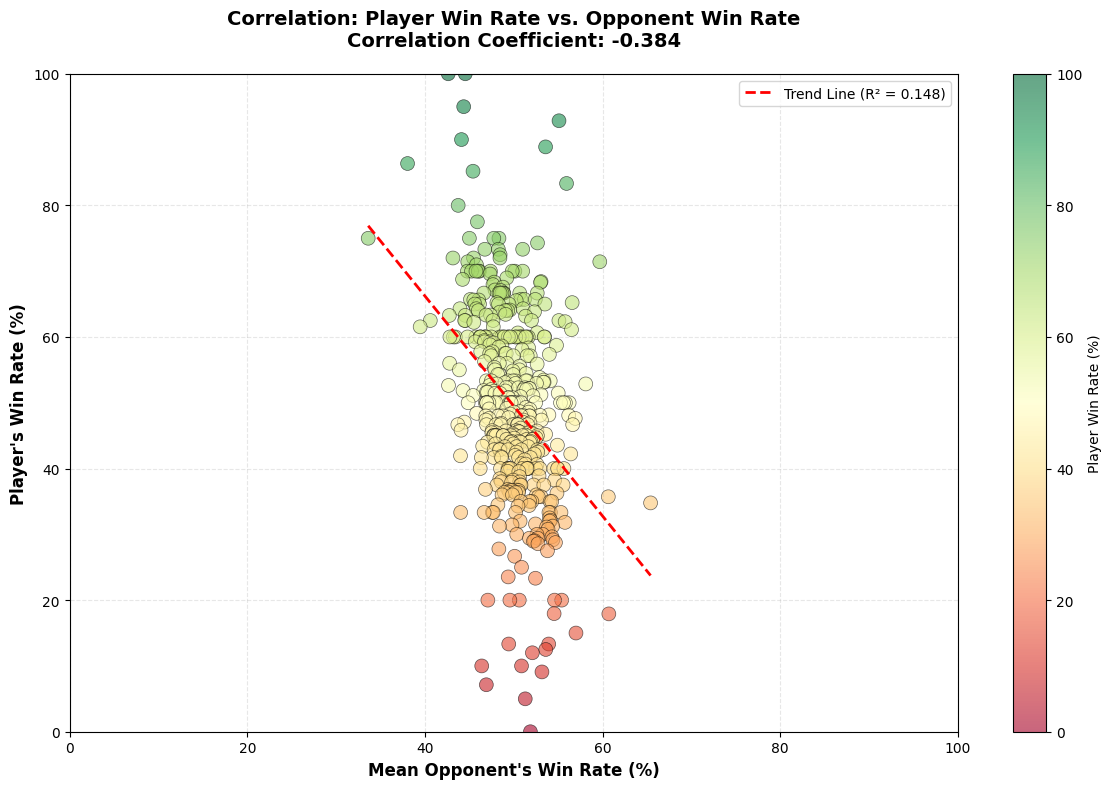


CORRELATION STATISTICS
Pearson Correlation Coefficient: -0.3843
R-squared (R²): 0.1477
Slope: -1.6721
Intercept: 133.0985

Interpretation: There is a moderate negative correlation between
a player's win rate and their opponents' mean win rate.


In [17]:
# Visualization: Correlation between Player's Win Rate and Opponent's Win Rate (with trend line)

import matplotlib.pyplot as plt

# Prepare data for visualization
x = enhanced_df['Mean Opponent\'s Win Rate']
y = enhanced_df['Win Rate']

# Calculate correlation coefficient manually
def calculate_correlation(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)
    sum_y2 = np.sum(y ** 2)
    
    numerator = n * sum_xy - sum_x * sum_y
    denominator = np.sqrt((n * sum_x2 - sum_x ** 2) * (n * sum_y2 - sum_y ** 2))
    
    if denominator == 0:
        return 0
    return numerator / denominator

# Calculate linear regression manually
def calculate_linear_regression(x, y):
    n = len(x)
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    numerator = np.sum((x - mean_x) * (y - mean_y))
    denominator = np.sum((x - mean_x) ** 2)
    
    slope = numerator / denominator if denominator != 0 else 0
    intercept = mean_y - slope * mean_x
    
    # Calculate R-squared
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - mean_y) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    return slope, intercept, r_squared

correlation = calculate_correlation(x.values, y.values)
slope, intercept, r_squared = calculate_linear_regression(x.values, y.values)

# Create the scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(x, y, alpha=0.6, s=100, c=y, cmap='RdYlGn', edgecolors='black', linewidth=0.5)

# Add trend line
line_x = np.array([x.min(), x.max()])
line_y = slope * line_x + intercept
plt.plot(line_x, line_y, 'r--', linewidth=2, label=f'Trend Line (R² = {r_squared:.3f})')

# Customize the plot
plt.xlabel('Mean Opponent\'s Win Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Player\'s Win Rate (%)', fontsize=12, fontweight='bold')
plt.title('Correlation: Player Win Rate vs. Opponent Win Rate\n' + 
          f'Correlation Coefficient: {correlation:.3f}', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.colorbar(scatter, label='Player Win Rate (%)')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print correlation statistics
print("\n" + "="*100)
print("CORRELATION STATISTICS")
print("="*100)
print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"R-squared (R²): {r_squared:.4f}")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

if abs(correlation) < 0.3:
    strength = "weak"
elif abs(correlation) < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if correlation > 0 else "negative"

print(f"\nInterpretation: There is a {strength} {direction} correlation between")
print(f"a player's win rate and their opponents' mean win rate.")
print("="*100)

Dataset size: 7851 matches
Class balance — P1 wins: 49.7%  |  P2 wins: 50.3%

Train size: 6280  |  Test size: 1571

MODEL EVALUATION
Accuracy:  64.74%

Classification Report:
              precision    recall  f1-score   support

Player2 Wins       0.65      0.64      0.65       791
Player1 Wins       0.64      0.65      0.65       780

    accuracy                           0.65      1571
   macro avg       0.65      0.65      0.65      1571
weighted avg       0.65      0.65      0.65      1571

5-Fold CV Accuracy: 64.25% ± 0.88%


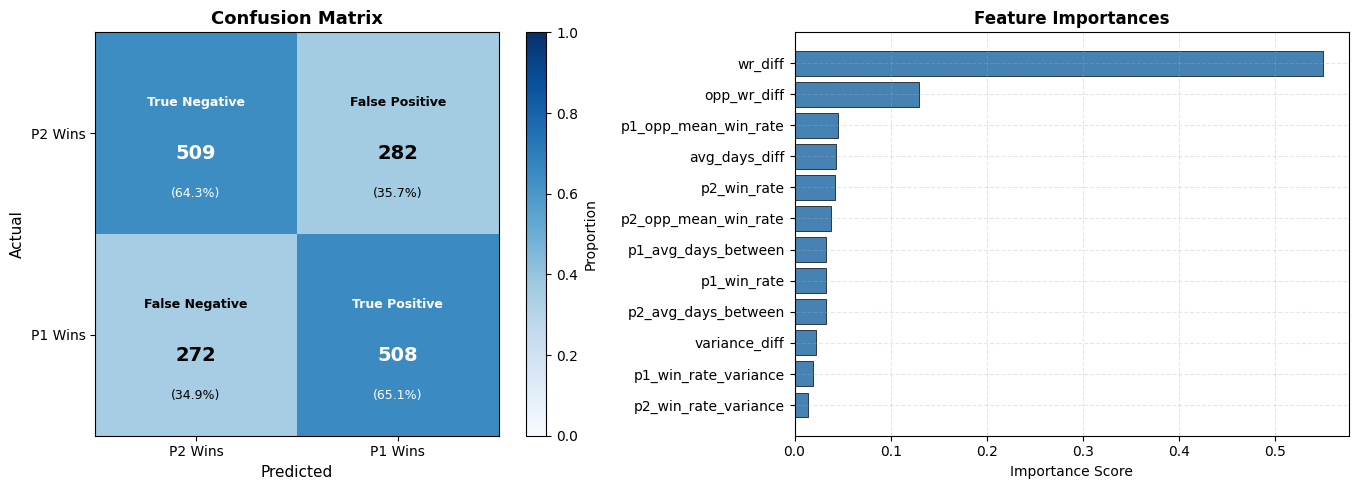

In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. BUILD MATCH-LEVEL DATASET
# ─────────────────────────────────────────────
# We need one row per match with features for BOTH players

# Build win rate lookup for all players (already done in your code)
all_player_winrates = {}
all_players = set(df['Player1'].unique()) | set(df['Player2'].unique())

for player in all_players:
    p1 = df[df['Player1'] == player].copy()
    p2 = df[df['Player2'] == player].copy()
    p1['won'] = p1['HomeWinner'] == 1
    p2['won'] = p2['HomeWinner'] == 0
    matches = pd.concat([p1[['Date', 'won']], p2[['Date', 'won']]])
    total = len(matches)
    wins = matches['won'].sum()
    all_player_winrates[player] = (wins / total * 100) if total > 0 else 0

# Build opponent mean win rate lookup (from enhanced_df)
opponent_mean_winrate = dict(zip(enhanced_df['Player Name'], enhanced_df["Mean Opponent's Win Rate"]))
win_rate_variance     = dict(zip(enhanced_df['Player Name'], enhanced_df['Win Rate Variance']))
avg_days              = dict(zip(result_df['Player Name'],   result_df['Avg Days Between Matches']))

# ─────────────────────────────────────────────
# 2. CONSTRUCT FEATURE ROWS
# ─────────────────────────────────────────────
rows = []

for _, match in df.iterrows():
    p1  = match['Player1']
    p2  = match['Player2']
    won = int(match['HomeWinner'])  # 1 = Player1 wins, 0 = Player2 wins

    # Skip if either player missing from our stats
    if p1 not in all_player_winrates or p2 not in all_player_winrates:
        continue

    p1_wr  = all_player_winrates.get(p1, 50)
    p2_wr  = all_player_winrates.get(p2, 50)
    p1_owr = opponent_mean_winrate.get(p1, 50)
    p2_owr = opponent_mean_winrate.get(p2, 50)
    p1_var = win_rate_variance.get(p1, 0)
    p2_var = win_rate_variance.get(p2, 0)
    p1_avg = avg_days.get(p1, 0)
    p2_avg = avg_days.get(p2, 0)

    rows.append({
        # Player 1 features
        'p1_win_rate':              p1_wr,
        'p1_opp_mean_win_rate':     p1_owr,
        'p1_win_rate_variance':     p1_var,
        'p1_avg_days_between':      p1_avg,

        # Player 2 features
        'p2_win_rate':              p2_wr,
        'p2_opp_mean_win_rate':     p2_owr,
        'p2_win_rate_variance':     p2_var,
        'p2_avg_days_between':      p2_avg,

        # Differential features (often the most predictive)
        'wr_diff':                  p1_wr  - p2_wr,
        'opp_wr_diff':              p1_owr - p2_owr,
        'variance_diff':            p1_var - p2_var,
        'avg_days_diff':            p1_avg - p2_avg,

        # Target
        'target': won
    })

model_df = pd.DataFrame(rows)
print(f"Dataset size: {len(model_df)} matches")
print(f"Class balance — P1 wins: {model_df['target'].mean()*100:.1f}%  |  P2 wins: {(1-model_df['target'].mean())*100:.1f}%")

# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────
FEATURES = [
    'p1_win_rate', 'p1_opp_mean_win_rate', 'p1_win_rate_variance', 'p1_avg_days_between',
    'p2_win_rate', 'p2_opp_mean_win_rate', 'p2_win_rate_variance', 'p2_avg_days_between',
    'wr_diff', 'opp_wr_diff', 'variance_diff', 'avg_days_diff'
]

X = model_df[FEATURES]
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}")

# ─────────────────────────────────────────────
# 4. TRAIN GRADIENT BOOSTED TREES
# ─────────────────────────────────────────────
gbt = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

gbt.fit(X_train, y_train)

# ─────────────────────────────────────────────
# 5. EVALUATE
# ─────────────────────────────────────────────
y_pred = gbt.predict(X_test)
y_prob = gbt.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Player2 Wins', 'Player1 Wins']))

# Cross-validation
cv_scores = cross_val_score(gbt, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

# ─────────────────────────────────────────────
# 6. CONFUSION MATRIX (improved readability)
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use a diverging colormap and normalize
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

im = axes[0].imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['P2 Wins', 'P1 Wins'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['P2 Wins', 'P1 Wins'])

labels = [['True Negative', 'False Positive'],
          ['False Negative', 'True Positive']]

for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct   = cm_normalized[i, j] * 100
        label = labels[i][j]
        color = 'white' if cm_normalized[i, j] > 0.5 else 'black'

        # Label type (e.g. "False Positive") in bold
        axes[0].text(j, i - 0.15, label, ha='center', va='center',
                     fontsize=9, fontweight='bold', color=color)
        # Count
        axes[0].text(j, i + 0.1, str(count), ha='center', va='center',
                     fontsize=14, fontweight='bold', color=color)
        # Percentage
        axes[0].text(j, i + 0.3, f'({pct:.1f}%)', ha='center', va='center',
                     fontsize=9, color=color)

plt.colorbar(im, ax=axes[0], label='Proportion')

# ─────────────────────────────────────────────
# 7. FEATURE IMPORTANCE (unchanged)
# ─────────────────────────────────────────────
importance = pd.Series(gbt.feature_importances_, index=FEATURES).sort_values(ascending=True)
axes[1].barh(importance.index, importance.values, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_title('Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Building match dataset — this will take several minutes due to leak-free lookups...
  Processing match 0/7851...
  Processing match 500/7851...
  Processing match 1000/7851...
  Processing match 1500/7851...
  Processing match 2000/7851...
  Processing match 2500/7851...
  Processing match 3000/7851...
  Processing match 3500/7851...
  Processing match 4000/7851...
  Processing match 4500/7851...
  Processing match 5000/7851...
  Processing match 5500/7851...
  Processing match 6000/7851...
  Processing match 6500/7851...
  Processing match 7000/7851...
  Processing match 7500/7851...

Dataset size: 7851 matches
Class balance — P1 wins: 49.7%  |  P2 wins: 50.3%
Train size: 6280  |  Test size: 1571

Running hyperparameter search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.7}
Best CV accuracy: 58.61%

MODEL EVALUATION
Test Accuracy : 58.05%

Classification Report:
           

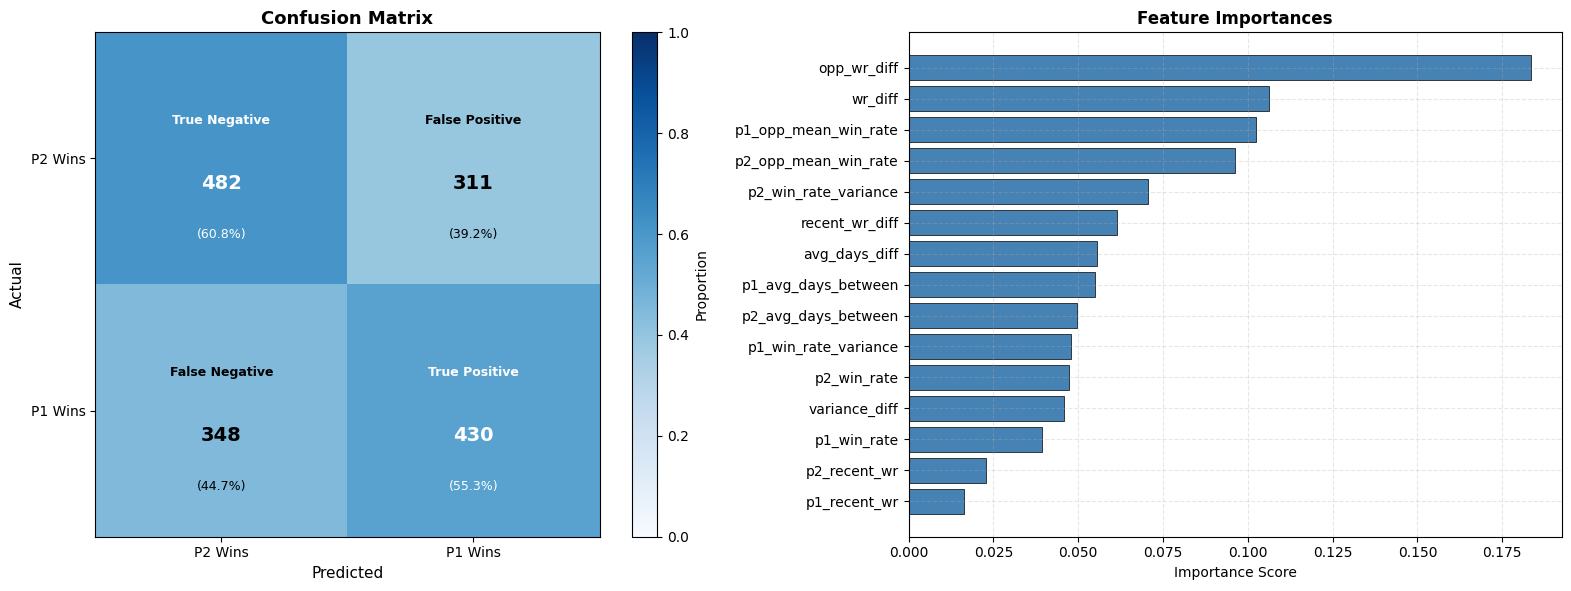

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. BUILD LOOKUPS
# ─────────────────────────────────────────────
opponent_mean_winrate = dict(zip(enhanced_df['Player Name'], enhanced_df["Mean Opponent's Win Rate"]))
win_rate_variance     = dict(zip(enhanced_df['Player Name'], enhanced_df['Win Rate Variance']))
avg_days              = dict(zip(result_df['Player Name'],   result_df['Avg Days Between Matches']))

# ─────────────────────────────────────────────
# 2. HELPER FUNCTIONS
# ─────────────────────────────────────────────
def get_past_matches(player, match_date, df):
    """Get all matches for a player strictly before match_date."""
    p1 = df[(df['Player1'] == player) & (df['Date'] < match_date)].copy()
    p2 = df[(df['Player2'] == player) & (df['Date'] < match_date)].copy()
    p1['won'] = p1['HomeWinner'] == 1
    p2['won'] = p2['HomeWinner'] == 0
    return pd.concat([p1[['Date', 'won']], p2[['Date', 'won']]]).sort_values('Date')

def get_career_winrate(player, match_date, df):
    """Career win rate using only past matches — no leakage."""
    past = get_past_matches(player, match_date, df)
    return past['won'].mean() * 100 if len(past) > 0 else 50

def get_rolling_winrate(player, match_date, df, window=10):
    """Win rate over last N matches before this date."""
    past = get_past_matches(player, match_date, df)
    recent = past.tail(window)
    return recent['won'].mean() * 100 if len(recent) > 0 else 50

# ─────────────────────────────────────────────
# 3. BUILD MATCH-LEVEL DATASET
# ─────────────────────────────────────────────
print("Building match dataset — this will take several minutes due to leak-free lookups...")

rows = []
total = len(df)

for idx, match in df.iterrows():
    p1   = match['Player1']
    p2   = match['Player2']
    won  = int(match['HomeWinner'])
    date = match['Date']

    if idx % 500 == 0:
        print(f"  Processing match {idx}/{total}...")

    # Career win rates (leak-free)
    p1_wr = get_career_winrate(p1, date, df)
    p2_wr = get_career_winrate(p2, date, df)

    # Opponent mean win rates
    p1_owr = opponent_mean_winrate.get(p1, 50)
    p2_owr = opponent_mean_winrate.get(p2, 50)

    # Variance and avg days
    p1_var = win_rate_variance.get(p1, 0)
    p2_var = win_rate_variance.get(p2, 0)
    p1_avg = avg_days.get(p1, 0)
    p2_avg = avg_days.get(p2, 0)

    # Recent form
    p1_recent = get_rolling_winrate(p1, date, df, window=10)
    p2_recent = get_rolling_winrate(p2, date, df, window=10)

    rows.append({
        # Career features
        'p1_win_rate':          p1_wr,
        'p2_win_rate':          p2_wr,
        'p1_opp_mean_win_rate': p1_owr,
        'p2_opp_mean_win_rate': p2_owr,
        'p1_win_rate_variance': p1_var,
        'p2_win_rate_variance': p2_var,
        'p1_avg_days_between':  p1_avg,
        'p2_avg_days_between':  p2_avg,

        # Recent form
        'p1_recent_wr':         p1_recent,
        'p2_recent_wr':         p2_recent,

        # Differentials
        'wr_diff':              p1_wr     - p2_wr,
        'opp_wr_diff':          p1_owr    - p2_owr,
        'variance_diff':        p1_var    - p2_var,
        'avg_days_diff':        p1_avg    - p2_avg,
        'recent_wr_diff':       p1_recent - p2_recent,

        'target': won
    })

model_df = pd.DataFrame(rows)
print(f"\nDataset size: {len(model_df)} matches")
print(f"Class balance — P1 wins: {model_df['target'].mean()*100:.1f}%  |  P2 wins: {(1-model_df['target'].mean())*100:.1f}%")

# ─────────────────────────────────────────────
# 4. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────
FEATURES = [
    'p1_win_rate', 'p2_win_rate',
    'p1_opp_mean_win_rate', 'p2_opp_mean_win_rate',
    'p1_win_rate_variance', 'p2_win_rate_variance',
    'p1_avg_days_between', 'p2_avg_days_between',
    'p1_recent_wr', 'p2_recent_wr',
    'wr_diff', 'opp_wr_diff', 'variance_diff',
    'avg_days_diff', 'recent_wr_diff'
]

X = model_df[FEATURES]
y = model_df['target']

# Chronological split
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# ─────────────────────────────────────────────
# 5. HYPERPARAMETER TUNING
# ─────────────────────────────────────────────
print("\nRunning hyperparameter search...")

param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 4],
    'subsample':     [0.7, 0.8]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_ * 100:.2f}%")

gbt = grid_search.best_estimator_

# ─────────────────────────────────────────────
# 6. EVALUATE
# ─────────────────────────────────────────────
y_pred = gbt.predict(X_test)

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Player2 Wins', 'Player1 Wins']))

cv_scores = cross_val_score(gbt, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

# ─────────────────────────────────────────────
# 7. VISUALIZATIONS
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['P2 Wins', 'P1 Wins'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['P2 Wins', 'P1 Wins'])

labels = [['True Negative',  'False Positive'],
          ['False Negative', 'True Positive']]

for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct   = cm_normalized[i, j] * 100
        label = labels[i][j]
        color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
        axes[0].text(j, i - 0.15, label,            ha='center', va='center', fontsize=9,  fontweight='bold', color=color)
        axes[0].text(j, i + 0.10, str(count),        ha='center', va='center', fontsize=14, fontweight='bold', color=color)
        axes[0].text(j, i + 0.30, f'({pct:.1f}%)',  ha='center', va='center', fontsize=9,  color=color)

plt.colorbar(im, ax=axes[0], label='Proportion')

# Feature importance
importance = pd.Series(gbt.feature_importances_, index=FEATURES).sort_values(ascending=True)
axes[1].barh(importance.index, importance.values, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_title('Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. PREDICT A MATCH
# ─────────────────────────────────────────────
def predict_match(player1, player2):
    if player1 not in set(df['Player1']) | set(df['Player2']) or \
       player2 not in set(df['Player1']) | set(df['Player2']):
        print("One or both players not found in dataset.")
        return

    latest_date = df['Date'].max() + pd.Timedelta(days=1)

    p1_wr     = get_career_winrate(player1, latest_date, df)
    p2_wr     = get_career_winrate(player2, latest_date, df)
    p1_owr    = opponent_mean_winrate.get(player1, 50)
    p2_owr    = opponent_mean_winrate.get(player2, 50)
    p1_var    = win_rate_variance.get(player1, 0)
    p2_var    = win_rate_variance.get(player2, 0)
    p1_avg    = avg_days.get(player1, 0)
    p2_avg    = avg_days.get(player2, 0)
    p1_recent = get_rolling_winrate(player1, latest_date, df, window=10)
    p2_recent = get_rolling_winrate(player2, latest_date, df, window=10)

    features = pd.DataFrame([{
        'p1_win_rate':          p1_wr,
        'p2_win_rate':          p2_wr,
        'p1_opp_mean_win_rate': p1_owr,
        'p2_opp_mean_win_rate': p2_owr,
        'p1_win_rate_variance': p1_var,
        'p2_win_rate_variance': p2_var,
        'p1_avg_days_between':  p1_avg,
        'p2_avg_days_between':  p2_avg,
        'p1_recent_wr':         p1_recent,
        'p2_recent_wr':         p2_recent,
        'wr_diff':              p1_wr     - p2_wr,
        'opp_wr_diff':          p1_owr    - p2_owr,
        'variance_diff':        p1_var    - p2_var,
        'avg_days_diff':        p1_avg    - p2_avg,
        'recent_wr_diff':       p1_recent - p2_recent,
    }])

    prob   = gbt.predict_proba(features)[0]
    winner = player1 if prob[1] >= 0.5 else player2

    print(f"\n{'='*55}")
    print(f"  {player1}  vs  {player2}")
    print(f"  → Predicted winner      : {winner}")
    print(f"  → {player1} win prob    : {prob[1]*100:.1f}%")
    print(f"  → {player2} win prob    : {prob[0]*100:.1f}%")
    print(f"  → {player1} career WR   : {p1_wr:.1f}%  | recent (10): {p1_recent:.1f}%")
    print(f"  → {player2} career WR   : {p2_wr:.1f}%  | recent (10): {p2_recent:.1f}%")
    print(f"{'='*55}")

# predict_match('PlayerA', 'PlayerB')

Building match dataset — this will take several minutes due to leak-free lookups...
  Processing match 0/7851...
  Processing match 500/7851...
  Processing match 1000/7851...
  Processing match 1500/7851...
  Processing match 2000/7851...
  Processing match 2500/7851...
  Processing match 3000/7851...
  Processing match 3500/7851...
  Processing match 4000/7851...
  Processing match 4500/7851...
  Processing match 5000/7851...
  Processing match 5500/7851...
  Processing match 6000/7851...
  Processing match 6500/7851...
  Processing match 7000/7851...
  Processing match 7500/7851...

Dataset size: 7851 matches
Class balance — P1 wins: 49.7%  |  P2 wins: 50.3%
      p1_win_rate  p2_win_rate  p1_opp_mean_win_rate  p2_opp_mean_win_rate  \
0       50.000000    50.000000                 52.61                 51.22   
1       50.000000    50.000000                 47.89                 52.42   
2       50.000000    50.000000                 46.05                 49.87   
3       50.000000 

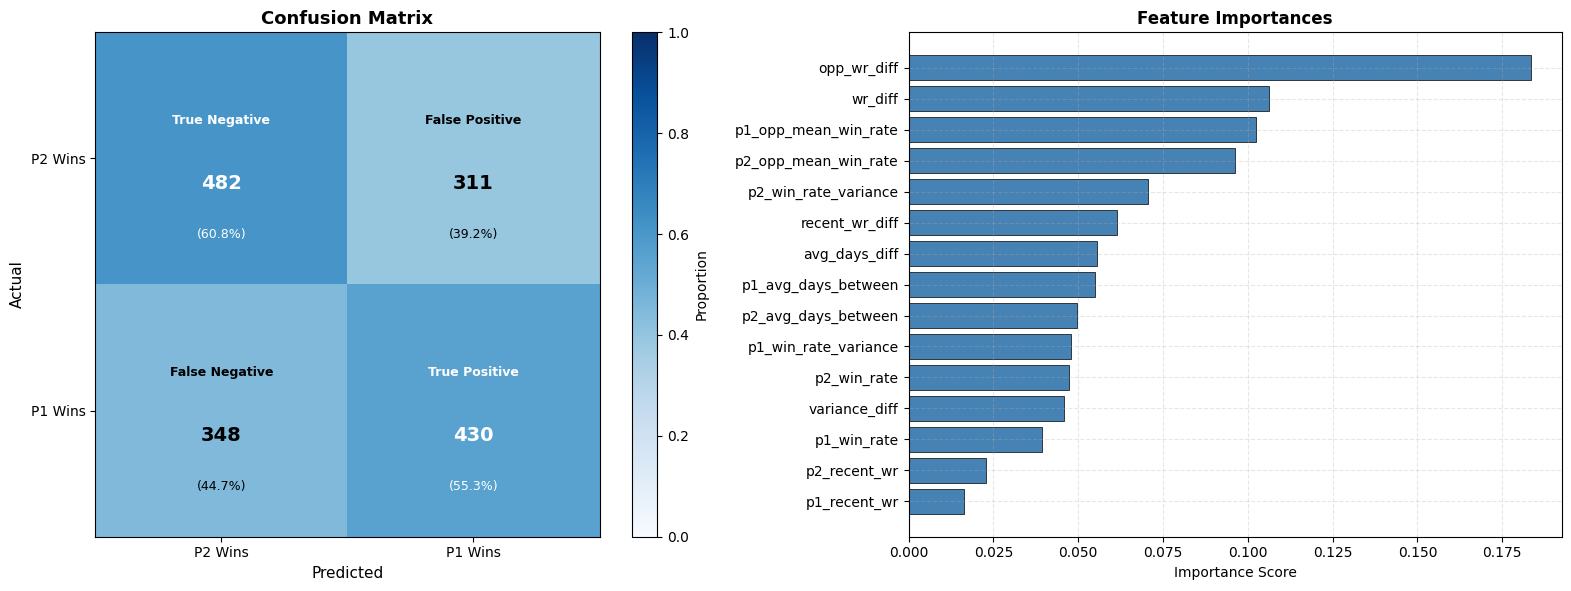

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. BUILD LOOKUPS
# ─────────────────────────────────────────────
opponent_mean_winrate = dict(zip(enhanced_df['Player Name'], enhanced_df["Mean Opponent's Win Rate"]))
win_rate_variance     = dict(zip(enhanced_df['Player Name'], enhanced_df['Win Rate Variance']))
avg_days              = dict(zip(result_df['Player Name'],   result_df['Avg Days Between Matches']))

# ─────────────────────────────────────────────
# 2. HELPER FUNCTIONS
# ─────────────────────────────────────────────
def get_past_matches(player, match_date, df):
    """Get all matches for a player strictly before match_date."""
    p1 = df[(df['Player1'] == player) & (df['Date'] < match_date)].copy()
    p2 = df[(df['Player2'] == player) & (df['Date'] < match_date)].copy()
    p1['won'] = p1['HomeWinner'] == 1
    p2['won'] = p2['HomeWinner'] == 0
    return pd.concat([p1[['Date', 'won']], p2[['Date', 'won']]]).sort_values('Date')

def get_career_winrate(player, match_date, df):
    """Career win rate using only past matches — no leakage."""
    past = get_past_matches(player, match_date, df)
    return past['won'].mean() * 100 if len(past) > 0 else 50

def get_rolling_winrate(player, match_date, df, window=10):
    """Win rate over last N matches before this date."""
    past = get_past_matches(player, match_date, df)
    recent = past.tail(window)
    return recent['won'].mean() * 100 if len(recent) > 0 else 50

# ─────────────────────────────────────────────
# 3. BUILD MATCH-LEVEL DATASET
# ─────────────────────────────────────────────
print("Building match dataset — this will take several minutes due to leak-free lookups...")

rows = []
total = len(df)

for idx, match in df.iterrows():
    p1   = match['Player1']
    p2   = match['Player2']
    won  = int(match['HomeWinner'])
    date = match['Date']

    if idx % 500 == 0:
        print(f"  Processing match {idx}/{total}...")

    # Career win rates (leak-free)
    p1_wr = get_career_winrate(p1, date, df)
    p2_wr = get_career_winrate(p2, date, df)

    # Opponent mean win rates
    p1_owr = opponent_mean_winrate.get(p1, 50)
    p2_owr = opponent_mean_winrate.get(p2, 50)

    # Variance and avg days
    p1_var = win_rate_variance.get(p1, 0)
    p2_var = win_rate_variance.get(p2, 0)
    p1_avg = avg_days.get(p1, 0)
    p2_avg = avg_days.get(p2, 0)

    # Recent form
    p1_recent = get_rolling_winrate(p1, date, df, window=10)
    p2_recent = get_rolling_winrate(p2, date, df, window=10)

    rows.append({
        # Career features
        'p1_win_rate':          p1_wr,
        'p2_win_rate':          p2_wr,
        'p1_opp_mean_win_rate': p1_owr,
        'p2_opp_mean_win_rate': p2_owr,
        'p1_win_rate_variance': p1_var,
        'p2_win_rate_variance': p2_var,
        'p1_avg_days_between':  p1_avg,
        'p2_avg_days_between':  p2_avg,

        # Recent form
        'p1_recent_wr':         p1_recent,
        'p2_recent_wr':         p2_recent,

        # Differentials
        'wr_diff':              p1_wr     - p2_wr,
        'opp_wr_diff':          p1_owr    - p2_owr,
        'variance_diff':        p1_var    - p2_var,
        'avg_days_diff':        p1_avg    - p2_avg,
        'recent_wr_diff':       p1_recent - p2_recent,

        'target': won
    })

model_df = pd.DataFrame(rows)
print(f"\nDataset size: {len(model_df)} matches")
print(f"Class balance — P1 wins: {model_df['target'].mean()*100:.1f}%  |  P2 wins: {(1-model_df['target'].mean())*100:.1f}%")
print(model_df)
# ─────────────────────────────────────────────
# 4. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────
FEATURES = [
    'p1_win_rate', 'p2_win_rate',
    'p1_opp_mean_win_rate', 'p2_opp_mean_win_rate',
    'p1_win_rate_variance', 'p2_win_rate_variance',
    'p1_avg_days_between', 'p2_avg_days_between',
    'p1_recent_wr', 'p2_recent_wr',
    'wr_diff', 'opp_wr_diff', 'variance_diff',
    'avg_days_diff', 'recent_wr_diff'
]

X = model_df[FEATURES]
y = model_df['target']

# Chronological split
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

# ─────────────────────────────────────────────
# 5. HYPERPARAMETER TUNING
# ─────────────────────────────────────────────
print("\nRunning hyperparameter search...")

param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 4],
    'subsample':     [0.7, 0.8]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_ * 100:.2f}%")

gbt = grid_search.best_estimator_

# ─────────────────────────────────────────────
# 6. EVALUATE
# ─────────────────────────────────────────────
y_pred = gbt.predict(X_test)

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Player2 Wins', 'Player1 Wins']))

cv_scores = cross_val_score(gbt, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

# ─────────────────────────────────────────────
# 7. VISUALIZATIONS
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['P2 Wins', 'P1 Wins'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['P2 Wins', 'P1 Wins'])

labels = [['True Negative',  'False Positive'],
          ['False Negative', 'True Positive']]

for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct   = cm_normalized[i, j] * 100
        label = labels[i][j]
        color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
        axes[0].text(j, i - 0.15, label,            ha='center', va='center', fontsize=9,  fontweight='bold', color=color)
        axes[0].text(j, i + 0.10, str(count),        ha='center', va='center', fontsize=14, fontweight='bold', color=color)
        axes[0].text(j, i + 0.30, f'({pct:.1f}%)',  ha='center', va='center', fontsize=9,  color=color)

plt.colorbar(im, ax=axes[0], label='Proportion')

# Feature importance
importance = pd.Series(gbt.feature_importances_, index=FEATURES).sort_values(ascending=True)
axes[1].barh(importance.index, importance.values, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_title('Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. PREDICT A MATCH
# ─────────────────────────────────────────────
def predict_match(player1, player2):
    if player1 not in set(df['Player1']) | set(df['Player2']) or \
       player2 not in set(df['Player1']) | set(df['Player2']):
        print("One or both players not found in dataset.")
        return

    latest_date = df['Date'].max() + pd.Timedelta(days=1)

    p1_wr     = get_career_winrate(player1, latest_date, df)
    p2_wr     = get_career_winrate(player2, latest_date, df)
    p1_owr    = opponent_mean_winrate.get(player1, 50)
    p2_owr    = opponent_mean_winrate.get(player2, 50)
    p1_var    = win_rate_variance.get(player1, 0)
    p2_var    = win_rate_variance.get(player2, 0)
    p1_avg    = avg_days.get(player1, 0)
    p2_avg    = avg_days.get(player2, 0)
    p1_recent = get_rolling_winrate(player1, latest_date, df, window=10)
    p2_recent = get_rolling_winrate(player2, latest_date, df, window=10)

    features = pd.DataFrame([{
        'p1_win_rate':          p1_wr,
        'p2_win_rate':          p2_wr,
        'p1_opp_mean_win_rate': p1_owr,
        'p2_opp_mean_win_rate': p2_owr,
        'p1_win_rate_variance': p1_var,
        'p2_win_rate_variance': p2_var,
        'p1_avg_days_between':  p1_avg,
        'p2_avg_days_between':  p2_avg,
        'p1_recent_wr':         p1_recent,
        'p2_recent_wr':         p2_recent,
        'wr_diff':              p1_wr     - p2_wr,
        'opp_wr_diff':          p1_owr    - p2_owr,
        'variance_diff':        p1_var    - p2_var,
        'avg_days_diff':        p1_avg    - p2_avg,
        'recent_wr_diff':       p1_recent - p2_recent,
    }])

    prob   = gbt.predict_proba(features)[0]
    winner = player1 if prob[1] >= 0.5 else player2

    print(f"\n{'='*55}")
    print(f"  {player1}  vs  {player2}")
    print(f"  → Predicted winner      : {winner}")
    print(f"  → {player1} win prob    : {prob[1]*100:.1f}%")
    print(f"  → {player2} win prob    : {prob[0]*100:.1f}%")
    print(f"  → {player1} career WR   : {p1_wr:.1f}%  | recent (10): {p1_recent:.1f}%")
    print(f"  → {player2} career WR   : {p2_wr:.1f}%  | recent (10): {p2_recent:.1f}%")
    print(f"{'='*55}")

# predict_match('PlayerA', 'PlayerB')